In [13]:
pip install mysql-connector-python 

Note: you may need to restart the kernel to use updated packages.


# Connect Python to MySQL

In [ ]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Your_Password",
    database="traffic_accident_data"
)

query = "SELECT * FROM traffic_accident_data "
df = pd.read_sql(query, conn)
df.head()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df.shape

(1200, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   accident_id        1200 non-null   int64 
 1   date               1200 non-null   object
 2   time               1200 non-null   object
 3   city               1200 non-null   object
 4   state              1200 non-null   object
 5   weather            1200 non-null   object
 6   road_condition     1200 non-null   object
 7   light_condition    1200 non-null   object
 8   vehicle_type       1200 non-null   object
 9   accident_severity  1200 non-null   object
 10  casualties         1200 non-null   int64 
dtypes: int64(2), object(9)
memory usage: 103.3+ KB


In [9]:
df.describe()

,accident_id,casualties
count,1200.000000,1200.000000
mean,600.500000,4.960000
std,346.554469,3.124079
min,1.000000,0.000000
25%,300.750000,2.000000
50%,600.500000,5.000000
75%,900.250000,8.000000
max,1200.000000,10.000000


# Data Cleaning

In [12]:
# Check missing values
df.isnull().sum()

accident_id          0
date                 0
time                 0
city                 0
state                0
weather              0
road_condition       0
light_condition      0
vehicle_type         0
accident_severity    0
casualties           0
dtype: int64

In [14]:
# Handling missing values
df.fillna({
    'weather': 'Unknown',
    'road_condition': 'Unknown',
    'casualties': 0
}, inplace=True)


# Feature Engineering

In [17]:
df['accident_date'] = pd.to_datetime(df['date'])
df['day'] = df['accident_date'].dt.day_name()
df['month'] = df['accident_date'].dt.month
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

In [19]:
df[['date', 'accident_date', 'day', 'month', 'hour']].head()

,date,accident_date,day,month,hour
0,2023-05-19,2023-05-19,Friday,5,3
1,2024-03-21,2024-03-21,Thursday,3,1
2,2022-09-15,2022-09-15,Thursday,9,14
3,2023-06-09,2023-06-09,Friday,6,2
4,2023-12-19,2023-12-19,Tuesday,12,18


# Exploratory Data Analysis (EDA)

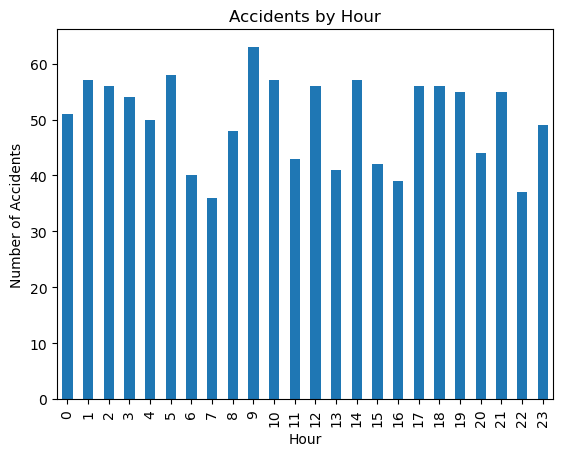

In [22]:
# 1.Accidents by Hour
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

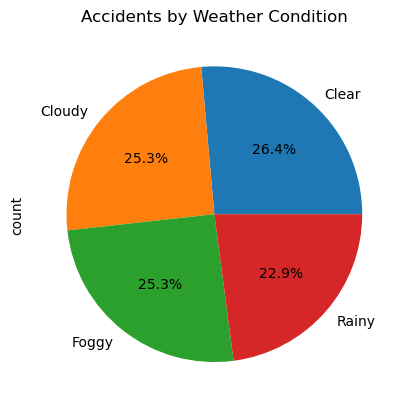

In [23]:
# 2. Accidents by Weather
df['weather'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Accidents by Weather Condition")
plt.show()

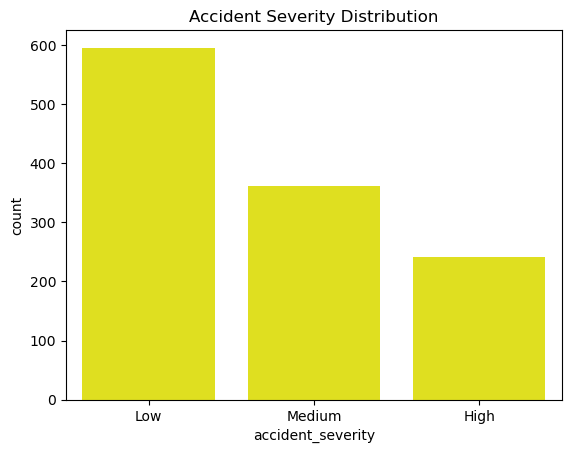

In [25]:
# 3.Severity Analysis
sns.countplot(x='accident_severity', data=df,color = "yellow")
plt.title("Accident Severity Distribution")
plt.show()

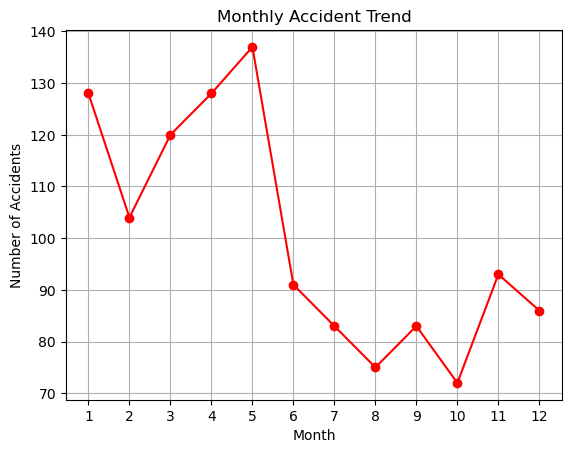

In [28]:
# 4.Monthly Accident Trend

monthly_accidents = df.groupby('month').size()

plt.plot(monthly_accidents.index, monthly_accidents.values, marker='o', color='red')
plt.title("Monthly Accident Trend")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


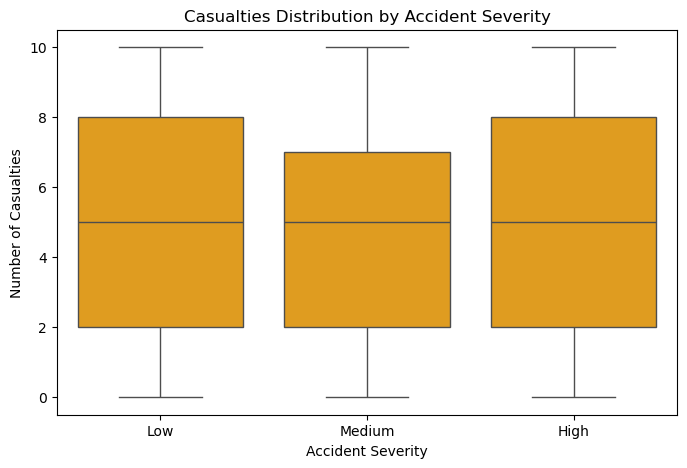

In [35]:
# 5.Casualties by Severity
plt.figure(figsize=(8,5))
sns.boxplot(x='accident_severity', y='casualties', data=df,color = 'orange')
plt.title("Casualties Distribution by Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Casualties")
plt.show()

# Export Cleaned Data for PowerBI

In [65]:
import os

print(os.getcwd())

C:\Users\Pooja


In [67]:
import os

output_file = r"C:\Users\Pooja\Downloads\cleaned_traffic_accidents.csv"

df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("File saved successfully!")
print(output_file)

File saved successfully!
C:\Users\Pooja\Downloads\cleaned_traffic_accidents.csv


In [69]:
import os

print(os.path.exists(output_file))

True


In [71]:
with open(output_file, "r", encoding="utf-8-sig") as f:
    print(f.readline())
    print(f.readline())

accident_id,date,time,city,state,weather,road_condition,light_condition,vehicle_type,accident_severity,casualties,accident_date,day,month,hour

1,2023-05-19,03:04:00,Hyderabad,Telangana,Cloudy,Damaged,Daylight,Truck,Low,6,2023-05-19,Friday,5,3

